In [1]:
import analysis
import os

In [2]:
directory = "C:\\Users\\theru\\julianarhee\\data\\20250908"

tag_1 = "20250910_114728"
tag_2 = "20250910_120252"

filename_1 = tag_1 + "_20250908_Dmel_R35D04-R22D06-RSET-GCaMP8m_005.h5"
filename_2 = tag_2 + "_20250908_Dmel_R35D04-R22D06-RSET-GCaMP8m_005.h5"

filepath_1 = os.path.join(directory, filename_1)
filepath_2 = os.path.join(directory, filename_2)   

json_filename_1 = tag_1 + "_experiment_config.json"
json_filepath_1 = os.path.join(directory, json_filename_1)

json_filename_2 = tag_2 + "_experiment_config.json"
json_filepath_2 = os.path.join(directory, json_filename_2)

In [3]:
# Summarize the file
analysis.summarize_noise_file(filepath_1)
# show_frame(filepath_1, frame_number=41)
duplicates = analysis.find_duplicate_timestamp_frames(filepath_1)

if duplicates:
    print(f"Total duplicates: {len(duplicates)}")
else:
    print("All timestamps are unique.")


Summary of file: C:\Users\theru\julianarhee\data\20250908\20250910_114728_20250908_Dmel_R35D04-R22D06-RSET-GCaMP8m_005.h5
----------------------------------------
Total frames saved: 48297
Frame numbers: 0 → 48296
Timestamps: 41491580334700 → 42091547895700
Original images stored: 48297
Bowl images stored:     48297
Groups in file: ['bowl_images', 'frame_numbers', 'is_new_frame', 'original_images', 'timestamps']
No duplicate timestamps found.
All timestamps are unique.


--- New Frame Comparison (C:\Users\theru\julianarhee\data\20250908\20250910_114728_20250908_Dmel_R35D04-R22D06-RSET-GCaMP8m_005.h5 vs C:\Users\theru\julianarhee\data\20250908\20250910_120252_20250908_Dmel_R35D04-R22D06-RSET-GCaMP8m_005.h5) ---
Idx    0 | File1 Frame      0, Time   60046.81 ms | File2 Frame      0, Time   60037.27 ms | Δ =     9.54 ms
Idx    1 | File1 Frame      5, Time   60132.91 ms | File2 Frame      5, Time   60120.49 ms | Δ =    12.43 ms
Idx    2 | File1 Frame     13, Time   60225.91 ms | File2 Frame     11, Time   60215.96 ms | Δ =     9.94 ms
Idx    3 | File1 Frame     19, Time   60321.50 ms | File2 Frame     18, Time   60311.01 ms | Δ =    10.49 ms
Idx    4 | File1 Frame     26, Time   60433.81 ms | File2 Frame     25, Time   60421.84 ms | Δ =    11.97 ms
Idx    5 | File1 Frame     34, Time   60529.34 ms | File2 Frame     32, Time   60515.62 ms | Δ =    13.72 ms
Idx    6 | File1 Frame     41, Time   60627.51 ms | File2 Frame     42, Time   60613.23 ms | Δ =    14

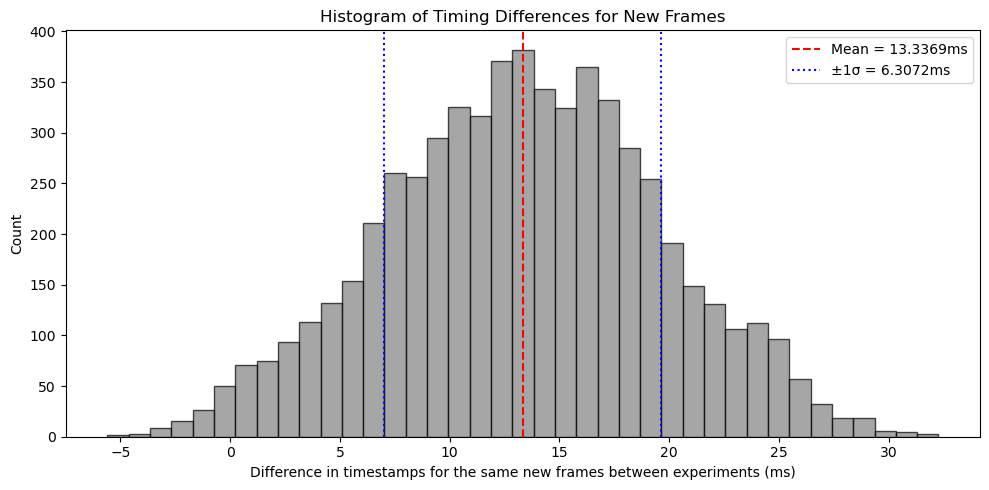

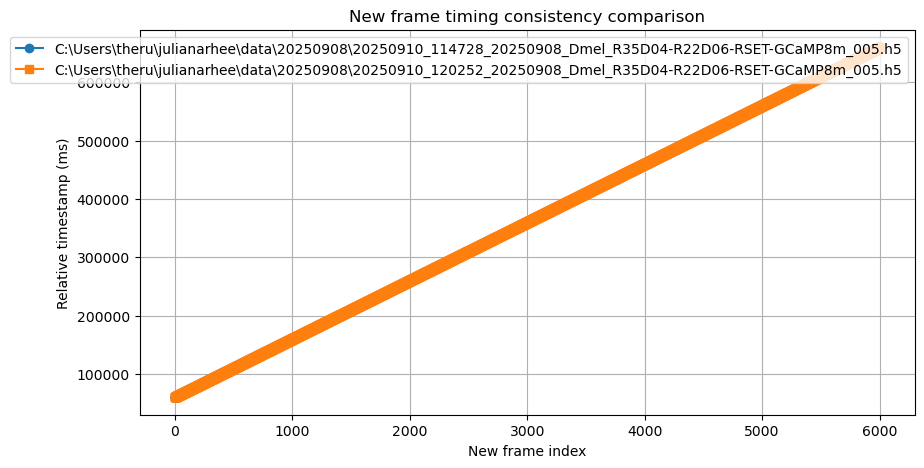

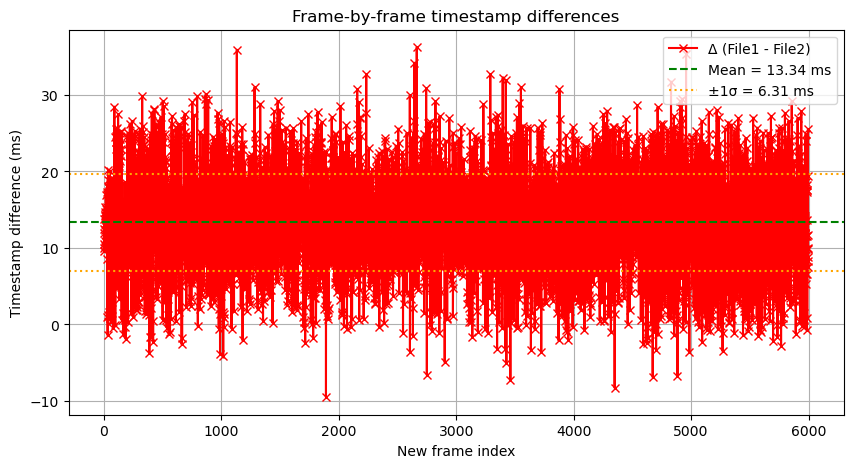

In [4]:
analysis.compare_frame_files(filepath_1, filepath_2, json_filepath_1, json_filepath_2)
# analysis.play_new_frame_comparison(filepath_1, filepath_2, fps=10)

In [5]:
analysis.subtract_images(filepath_1, filepath_2)

--- Frame Subtraction Comparison (C:\Users\theru\julianarhee\data\20250908\20250910_114728_20250908_Dmel_R35D04-R22D06-RSET-GCaMP8m_005.h5 vs C:\Users\theru\julianarhee\data\20250908\20250910_120252_20250908_Dmel_R35D04-R22D06-RSET-GCaMP8m_005.h5) ---
--- End of comparison ---


In [ ]:
t0, t0_d = analysis.get_first_frame_relative_time(json_filepath_1, filepath_1)
print(f"First frame relative to trigger: {t0:.6f} seconds")
print(f"First frame relative to trigger (subtracting dark screen time): {t0_d:.6f} seconds")

In [ ]:
import json
import h5py
import numpy as np
import matplotlib.pyplot as plt

def plot_frame_timing(hdf5_path: str, json_path: str):
    """
    Plot expected vs observed new frame timestamps relative to trigger,
    and show histogram + time-series of timing differences.

    Parameters
    ----------
    hdf5_path : str
        Path to the HDF5 file written by noise_pattern_writer.
    json_path : str
        Path to the experiment config JSON file.
    """
    # --- Load experiment metadata ---
    with open(json_path, "r", encoding="utf-8") as f:
        config = json.load(f)

    duration_s = config["duration_s"]
    dark_s = config["dark_screen_duration_s"]
    framerate = config["noise"]["framerate"]

    trigger_ns = config["arduino"]["hardware_trigger_2p_time"]

    # --- Load observed frame metadata from HDF5 ---
    with h5py.File(hdf5_path, "r") as f:
        timestamps = f["timestamps"][:]       # int64 ns
        is_new = f["is_new_frame"][:]         # 1=new frame, 0=repeat

    # Filter only "new" frames
    new_frame_times_ns = timestamps[is_new == 1]

    # Convert to seconds relative to trigger
    observed_times = (new_frame_times_ns - trigger_ns) / 1e9

    # --- Compute expected frame times ---
    frame_interval = 1.0 / framerate
    expected_times = np.arange(dark_s, duration_s, frame_interval)

    # --- Compute differences ---
    diffs = observed_times - expected_times
    mean_diff = np.mean(diffs)
    std_diff = np.std(diffs)

    print(f"Mean difference (observed - expected): {mean_diff:.6f} s")
    print(f"Std deviation of difference: {std_diff:.6f} s")

    # --- Plot 1: Expected vs Observed times ---
    plt.figure(figsize=(12, 4))
    plt.eventplot([expected_times, observed_times],
                  lineoffsets=[0, 0],
                  linelengths=[0.6, 0.6],
                  colors=["blue", "red"])
    plt.axvline(0, color="green", linestyle="--", label="Trigger (t=0)")
    plt.xlabel("Time relative to trigger (s)")
    plt.yticks([])
    plt.title("Expected (blue) vs Observed (red) Frame Timestamps")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Plot 2: Histogram of timing differences ---
    plt.figure(figsize=(8, 4))
    bins = np.linspace(mean_diff - 3*std_diff, mean_diff + 3*std_diff, 40)
    plt.hist(diffs, bins=bins, color="gray", edgecolor="black", alpha=0.7)
    plt.axvline(mean_diff, color="red", linestyle="--", label=f"Mean = {mean_diff:.4f}s")
    plt.axvline(mean_diff - std_diff, color="blue", linestyle=":", label=f"±1σ = {std_diff:.4f}s")
    plt.axvline(mean_diff + std_diff, color="blue", linestyle=":")
    plt.xlabel("Observed - Expected Time (s)")
    plt.ylabel("Count")
    plt.title("Histogram of Frame Timing Differences")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Plot 3: Time series of differences ---
    plt.figure(figsize=(12, 4))
    plt.plot(range(len(observed_times)), diffs, marker="o", markersize=2, linestyle="-", color="purple")
    plt.axhline(mean_diff, color="red", linestyle="--", label=f"Mean = {mean_diff:.4f}s")
    plt.axhline(mean_diff + std_diff, color="blue", linestyle=":", label=f"±1σ = {std_diff:.4f}s")
    plt.axhline(mean_diff - std_diff, color="blue", linestyle=":")
    plt.xlabel("Frame index")
    plt.ylabel("Observed - Expected (s)")
    plt.title("Timing Difference vs Frame Index")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
plot_frame_timing(filepath_1, json_filepath_1)

In [ ]:
plot_frame_timing(filepath_2, json_filepath_2)